import and setup

In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
from jax import vmap, jit, grad
from jax.scipy.special import logsumexp
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
import optax
from flax import linen as nn
from flax.training import train_state
from tqdm import trange
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
jax.config.update('jax_enable_x64', True)

print("JAX version:", jax.__version__)
print("Available devices:", jax.devices())

JAX version: 0.6.2
Available devices: [CpuDevice(id=0)]


diffusion model setup

In [2]:
# Diffusion model parameters following the paper
t_0, t_1 = 0.0, 1.0
beta_0 = 0.1
beta_1 = 20.0

# Define diffusion schedules
log_alpha = lambda t: -0.5*t*beta_0-0.25*t**2*(beta_1-beta_0)
log_sigma = lambda t: jnp.log(t)
dlog_alphadt = jax.grad(lambda t: log_alpha(t).sum())
dlog_sigmadt = jax.grad(lambda t: log_sigma(t).sum())
gamma = lambda t: (1 + 0.5*t*beta_0 + 0.5*t**2*(beta_1-beta_0))

# Score function for 2D Gaussian
def score_model(x, t):
    """Score function ∇log q_t(x) for 2D Gaussian"""
    sigma_t = jnp.exp(log_sigma(t))
    return -x / (sigma_t**2 + 1e-8)

# Diffusion drift function
def f_schedule(x, t):
    """Base drift term f_t(x) = -dlog_alpha/dt * x"""
    return -dlog_alphadt(t) * x

reward function suite

In [3]:
def reward_function_center(x: jnp.ndarray, scale: float = 1.0) -> jnp.ndarray:
	"""Single optimum at origin; smooth quadratic peak."""
	return -0.5 * jnp.sum((x / scale) ** 2)

def reward_function_quadrants(
	x: jnp.ndarray,
	targets: jnp.ndarray | None = None,
	s2: float = 0.2
) -> jnp.ndarray:
	"""Multiple optima at four quadrant points; smooth via log-sum-exp of Gaussians."""
	if targets is None:
		targets = jnp.array([[2.0, 2.0], [-2.0, 2.0], [-2.0, -2.0], [2.0, -2.0]])
	diffs = targets - x[None, :]
	sq = jnp.sum(diffs ** 2, axis=1)
	return logsumexp(-sq / (2.0 * s2))

def reward_function_ring(x: jnp.ndarray, radius: float = 2.5, s2: float = 0.1) -> jnp.ndarray:
	"""Continuum of optima on a circle of given radius; smooth radial peak."""
	r = jnp.linalg.norm(x)
	return -((r - radius) ** 2) / (2.0 * s2)

# If your code references `reward_function_complex`, define it explicitly.
# You can point it to one of the above or construct a simple mixture.
def reward_function_complex(x: jnp.ndarray) -> jnp.ndarray:
	"""Example complex reward: mixture of quadrants and a weak ring."""
	return 0.7 * reward_function_quadrants(x) + 0.3 * reward_function_ring(x, radius=2.5, s2=0.2)

In [4]:
# Create JIT-compiled version for specific reward functions
@jax.jit
def fkc_sde_step_center(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end):
    """JIT-compiled version for center reward function"""
    return fkc_sde_step(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end, 
                       reward_function_center, grad_reward_center)

@jax.jit
def fkc_sde_step_quadrants(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end):
    """JIT-compiled version for quadrants reward function"""
    return fkc_sde_step(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end, 
                       reward_function_quadrants, grad_reward_quadrants)

@jax.jit
def fkc_sde_step_ring(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end):
    """JIT-compiled version for ring reward function"""
    return fkc_sde_step(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end, 
                       reward_function_ring, grad_reward_ring)

@jax.jit
def fkc_sde_step_complex(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end):
    """JIT-compiled version for complex reward function"""
    return fkc_sde_step(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end, 
                       reward_function_complex, grad_reward_complex)

# Create gradient functions
grad_reward_center = grad(reward_function_center)
grad_reward_quadrants = grad(reward_function_quadrants)
grad_reward_ring = grad(reward_function_ring)
grad_reward_complex = grad(reward_function_complex)

# Vectorized versions
vmap_grad_reward_center = vmap(grad_reward_center)
vmap_grad_reward_quadrants = vmap(grad_reward_quadrants)
vmap_grad_reward_ring = vmap(grad_reward_ring)
vmap_grad_reward_complex = vmap(grad_reward_complex)

beta schedule functions

In [5]:
@jax.jit
def beta_schedule(t, T_max=1.0, beta_start=1.0, beta_end=10.0):
    """Beta schedule: increases as t goes from 1 → 0"""
    return beta_start + (beta_end - beta_start) * (1.0 - t / T_max)

@jax.jit
def dbeta_dt_schedule(t, T_max=1.0, beta_start=1.0, beta_end=10.0):
    """Time derivative of beta schedule"""
    return -(beta_end - beta_start) / T_max

fkc sde core

In [6]:
def fkc_sde_step(rng, x_t, w_t, t, dt, T_max, beta_start, beta_end, reward_func, grad_reward_func):
    """
    Faithful implementation of FKC SDE equations (29-30) from the paper
    
    Equation 29: dx_t = σ_t²(∇log q_t(x_t) + (β_t/2)∇r(x_t)) dt - f_t(x_t) dt + σ_t dW_t
    Equation 30: dw_t = (∂β_t/∂t)r(x_t) dt - ⟨β_t∇r(x_t), f_t(x_t)⟩ dt + ⟨β_t∇r(x_t), (σ_t²/2)∇log q_t(x_t)⟩ dt
    """
    # Get current beta and its derivative
    current_beta = beta_schedule(t, T_max, beta_start, beta_end)
    dbeta_t = dbeta_dt_schedule(t, T_max, beta_start, beta_end)
    
    # Diffusion coefficients
    sigma_t = jnp.exp(log_sigma(t))
    sigma_sq = sigma_t**2
    
    # Compute reward and gradient
    r_xt = vmap(reward_func)(x_t)  # Shape: (batch_size,)
    grad_r_xt = vmap(grad_reward_func)(x_t)  # Shape: (batch_size, 2)
    
    # Score function
    score_xt = score_model(x_t, t)  # Shape: (batch_size, 2)
    
    # Base drift
    f_xt = f_schedule(x_t, t)  # Shape: (batch_size, 2)
    
    # Equation 29: State evolution
    drift_x = sigma_sq * (score_xt + (current_beta / 2.0) * grad_r_xt) - f_xt
    rng, subkey = jax.random.split(rng)
    dW_t = jax.random.normal(subkey, x_t.shape) * jnp.sqrt(dt)
    x_next = x_t + drift_x * dt + sigma_t * dW_t
    
    # Equation 30: Weight evolution
    term1 = dbeta_t * r_xt[:, None]  # (∂β/∂t)r(x_t)
    term2 = -jnp.sum(current_beta * grad_r_xt * f_xt, axis=1, keepdims=True)  # -⟨β∇r, f⟩
    term3 = jnp.sum(current_beta * grad_r_xt * (sigma_sq / 2.0) * score_xt, axis=1, keepdims=True)  # ⟨β∇r, (σ²/2)∇log q⟩
    
    dw_t = (term1 + term2 + term3) * dt
    w_next = w_t + dw_t
    
    return rng, x_next, w_next

exploration

In [7]:
def compute_pairwise_distances(positions):
    """Compute pairwise distances between all particles"""
    distances = jnp.linalg.norm(positions[:, None, :] - positions[None, :, :], axis=2)
    return distances

def select_exploration_particles(weights, positions, k, exploration_strength=0.1):
    """Select k particles for exploration based on diversity and low weights"""
    batch_size = weights.shape[0]
    
    # Identify low-weight particles (candidates for replacement)
    weight_threshold = jnp.percentile(weights, 20)  # Bottom 20% by weight
    low_weight_mask = weights < weight_threshold
    low_weight_indices = jnp.where(low_weight_mask)[0]
    
    if len(low_weight_indices) < k:
        # If not enough low-weight particles, use lowest k weights
        sorted_indices = jnp.argsort(weights)
        low_weight_indices = sorted_indices[:k]
    
    # Compute pairwise distances
    distances = compute_pairwise_distances(positions)
    
    # For each low-weight particle, find most distant particles
    exploration_candidates = []
    for idx in low_weight_indices:
        particle_distances = distances[idx]
        distant_indices = jnp.argsort(particle_distances)[-k:]
        exploration_candidates.extend(distant_indices)
    
    # Remove duplicates and select top k unique candidates
    unique_candidates = jnp.unique(jnp.array(exploration_candidates))
    selected_indices = unique_candidates[:k]
    
    return selected_indices

def adaptive_k_schedule(t, T_max=1.0, k_max=50, k_min=0):
    """Adaptive k schedule: high exploration early, pure exploitation late"""
    if t >= 0.5:  # Exploration phase
        k = k_max - (k_max - k_max/2) * (1.0 - t) / 0.5
    else:  # Exploitation phase
        k = k_max/2 - (k_max/2 - k_min) * (0.5 - t) / 0.5
    
    return int(jnp.clip(k, k_min, k_max))

resampling

In [8]:
from scipy.stats import qmc
sampler = qmc.Sobol(d=1, scramble=False)

@partial(jax.jit, static_argnums=0)
def sample_cat_sys(bs, key, logits):
    """Systematic resampling"""
    u = jax.random.uniform(key, shape=(1,))
    u = (u + 1/bs*jnp.arange(bs)) % 1
    bins = jnp.cumsum(nn.softmax(logits))
    ids = jnp.digitize(u, bins)
    return ids, None

def exploration_resampling(weights, positions, t, T_max=1.0, k_max=50, k_min=0):
    """Enhanced resampling with exploration mechanism"""
    batch_size = weights.shape[0]
    
    # Get adaptive k
    k = adaptive_k_schedule(t, T_max, k_max, k_min)
    
    if k == 0:
        # Pure exploitation: standard resampling
        key = random.PRNGKey(42)
        new_ids, _ = sample_cat_sys(batch_size, key, weights)
        return new_ids
    
    # Exploration + Exploitation hybrid
    exploration_indices = select_exploration_particles(weights, positions, k)
    
    # Standard resampling for all particles
    key = random.PRNGKey(42)
    new_ids, _ = sample_cat_sys(batch_size, key, weights)
    
    # Replace exploration particles with diverse ones
    for i, exp_idx in enumerate(exploration_indices):
        distances = jnp.linalg.norm(positions - positions[exp_idx], axis=1)
        diverse_idx = jnp.argmax(distances)
        new_ids = new_ids.at[exp_idx].set(diverse_idx)
    
    return new_ids

generation

In [9]:
def generate_fkc_samples(key, reward_func, grad_reward_func, reward_name,
                        n_steps=1000, bs=512, dt=1e-3, T_max=1.0, 
                        beta_start=1.0, beta_end=10.0, resample=True,
                        exploration=True, k_max=50, k_min=0):
    """Generate samples using FKC with exploration"""
    print(f"Generating with reward function: {reward_name}")
    
    # Select the appropriate JIT-compiled function based on reward name
    if "Center" in reward_name:
        fkc_step_fn = fkc_sde_step_center
    elif "Quadrant" in reward_name:
        fkc_step_fn = fkc_sde_step_quadrants
    elif "Ring" in reward_name:
        fkc_step_fn = fkc_sde_step_ring
    elif "Complex" in reward_name:
        fkc_step_fn = fkc_sde_step_complex
    else:
        # Fallback to non-JIT version
        fkc_step_fn = lambda rng, x_t, w_t, t, dt, T_max, beta_start, beta_end: fkc_sde_step(
            rng, x_t, w_t, t, dt, T_max, beta_start, beta_end, reward_func, grad_reward_func
        )
    
    # Initialize generation arrays
    key, ikey = random.split(key, num=2)
    x_gen = jnp.zeros((bs, n_steps + 1, 2))
    w_gen = jnp.zeros((bs, n_steps + 1, 1))

    # Initialize with noise (starting from t=1, going to t=0)
    x_gen = x_gen.at[:, 0, :].set(random.normal(ikey, shape=(bs, 2)))
    w_gen = w_gen.at[:, 0, :].set(0.0)

    # Time starts at t=1 and goes to t=0
    t = T_max

    for i in trange(n_steps, desc=f'FKC generation ({reward_name})'):
        key, *ikey = random.split(key, num=3)
        
        # Perform one step of FKC SDE
        key, x_next, w_next = fkc_step_fn(
            key, x_gen[:, i, :], w_gen[:, i, :], t, dt, T_max, 
            beta_start, beta_end
        )
        
        # Update arrays
        x_gen = x_gen.at[:, i+1, :].set(x_next)
        w_gen = w_gen.at[:, i+1, :].set(w_next)
        
        # Enhanced resampling with exploration
        if resample and i % 20 == 0:
            if exploration:
                new_ids = exploration_resampling(
                    w_gen[:, i+1, 0], x_gen[:, i+1, :], t, T_max, k_max, k_min
                )
            else:
                new_ids, _ = sample_cat_sys(bs, ikey[1], w_gen[:, i+1, 0])
            
            x_gen = x_gen.at[:, i+1, :].set(x_gen[new_ids, i+1, :])
            w_gen = w_gen.at[:, i+1, :].set(0.0)
        
        t -= dt
    
    return key, x_gen, w_gen

neural network

In [10]:
class RewardNetwork(nn.Module):
    """Neural network to learn reward functions from particle samples"""
    
    @nn.compact
    def __call__(self, x):
        # Input: x shape (batch_size, 2) - particle positions
        # Output: reward values for each particle
        
        # First hidden layer
        x = nn.Dense(128)(x)
        x = nn.relu(x)
        
        # Second hidden layer
        x = nn.Dense(128)(x)
        x = nn.relu(x)
        
        # Third hidden layer
        x = nn.Dense(64)(x)
        x = nn.relu(x)
        
        # Fourth hidden layer
        x = nn.Dense(32)(x)
        x = nn.relu(x)
        
        # Output layer - single reward value per particle
        reward = nn.Dense(1)(x)
        
        return reward.squeeze(-1)  # Remove last dimension to get shape (batch_size,)

def create_network():
    """Create and initialize the reward network"""
    network = RewardNetwork()
    key = random.PRNGKey(42)
    
    # Initialize with dummy input
    dummy_input = jnp.ones((1, 2))  # Single particle at (1,1)
    params = network.init(key, dummy_input)
    
    return network, params

# Test the network
network, params = create_network()

adversarial training

In [11]:
def generate_training_data(key, reward_func, grad_reward_func, reward_name,
                          num_temperatures=5, samples_per_temp=1000):
    """Generate training data at multiple temperatures"""
    print(f"Generating training data for {reward_name}")
    
    all_samples = []
    all_rewards = []
    all_temperatures = []
    
    # Sample at different temperatures
    beta_values = jnp.linspace(1.0, 10.0, num_temperatures)
    
    for beta_val in beta_values:
        key, x_gen, w_gen = generate_fkc_samples(
            key, reward_func, grad_reward_func, f"{reward_name}_beta_{beta_val:.1f}",
            n_steps=500, bs=samples_per_temp, dt=1e-3, T_max=1.0,
            beta_start=beta_val, beta_end=beta_val, resample=True,
            exploration=True, k_max=50, k_min=0
        )
        
        # Get final samples and their rewards
        final_samples = x_gen[:, -1, :]  # Shape: (samples_per_temp, 2)
        final_rewards = vmap(reward_func)(final_samples)  # Shape: (samples_per_temp,)
        
        all_samples.append(final_samples)
        all_rewards.append(final_rewards)
        all_temperatures.extend([beta_val] * samples_per_temp)
    
    # Concatenate all data
    all_samples = jnp.concatenate(all_samples, axis=0)  # Shape: (num_temperatures * samples_per_temp, 2)
    all_rewards = jnp.concatenate(all_rewards, axis=0)  # Shape: (num_temperatures * samples_per_temp,)
    all_temperatures = jnp.array(all_temperatures)  # Shape: (num_temperatures * samples_per_temp,)
    
    return key, all_samples, all_rewards, all_temperatures

def adversarial_loss(params, samples, true_rewards, network):
    """Adversarial loss: network learns to approximate true rewards"""
    predicted_rewards = network.apply(params, samples)
    loss = jnp.mean((predicted_rewards - true_rewards)**2)
    return loss

# Remove JIT compilation to avoid issues
def train_step(params, samples, true_rewards, network, optimizer, opt_state):
    """Single training step - no JIT compilation"""
    loss_fn = lambda p: adversarial_loss(p, samples, true_rewards, network)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, loss, new_opt_state

training loop

In [12]:
def train_reward_network(key, reward_func, grad_reward_func, reward_name,
                        num_epochs=100, batch_size=256, learning_rate=1e-3):
    """Train the reward network using adversarial training"""
    print(f"Training reward network for {reward_name}")
    
    # Generate training data
    key, samples, true_rewards, temperatures = generate_training_data(
        key, reward_func, grad_reward_func, reward_name,
        num_temperatures=5, samples_per_temp=1000
    )
    
    # Create network and optimizer
    network, params = create_network()
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(params)
    
    # Training loop
    losses = []
    num_batches = len(samples) // batch_size
    
    for epoch in trange(num_epochs, desc="Training"):
        epoch_losses = []
        
        # Shuffle data
        key, shuffle_key = random.split(key)
        indices = random.permutation(shuffle_key, len(samples))
        shuffled_samples = samples[indices]
        shuffled_rewards = true_rewards[indices]
        
        # Mini-batch training
        for batch_idx in range(num_batches):
            start_idx = batch_idx * batch_size
            end_idx = start_idx + batch_size
            
            batch_samples = shuffled_samples[start_idx:end_idx]
            batch_rewards = shuffled_rewards[start_idx:end_idx]
            
            # Training step - pass all required arguments
            params, loss, opt_state = train_step(params, batch_samples, batch_rewards, network, optimizer, opt_state)
            epoch_losses.append(loss)
        
        avg_loss = jnp.mean(jnp.array(epoch_losses))
        losses.append(avg_loss)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")
    
    # Return key as the first value to match expected unpacking
    return key, network, params, losses, samples, true_rewards

evaluation

In [13]:
def evaluate_network(network, params, reward_func, reward_name, 
                    x_range=(-3, 3), y_range=(-3, 3), resolution=100):
    """Evaluate network performance by comparing with true reward function"""
    # Create grid
    x = jnp.linspace(x_range[0], x_range[1], resolution)
    y = jnp.linspace(y_range[0], y_range[1], resolution)
    X, Y = jnp.meshgrid(x, y)
    points = jnp.stack([X.ravel(), Y.ravel()], axis=1)
    
    # Get predictions
    predicted_rewards = network.apply(params, points)
    true_rewards = vmap(reward_func)(points)
    
    # Reshape for plotting
    pred_grid = predicted_rewards.reshape(resolution, resolution)
    true_grid = true_rewards.reshape(resolution, resolution)
    
    # Compute error
    mse = jnp.mean((predicted_rewards - true_rewards)**2)
    mae = jnp.mean(jnp.abs(predicted_rewards - true_rewards))
    
    print(f"Evaluation for {reward_name}:")
    print(f"MSE: {mse:.6f}")
    print(f"MAE: {mae:.6f}")
    
    return pred_grid, true_grid, mse, mae

def plot_comparison(pred_grid, true_grid, reward_name, x_range=(-3, 3), y_range=(-3, 3)):
    """Plot comparison between predicted and true rewards"""
    x = jnp.linspace(x_range[0], x_range[1], pred_grid.shape[0])
    y = jnp.linspace(y_range[0], y_range[1], pred_grid.shape[1])
    X, Y = jnp.meshgrid(x, y)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Predicted rewards
    im1 = ax1.contourf(X, Y, pred_grid, levels=20, cmap='viridis')
    ax1.set_title(f'Predicted Rewards: {reward_name}')
    ax1.set_xlabel('x1')
    ax1.set_ylabel('x2')
    plt.colorbar(im1, ax=ax1)
    
    # True rewards
    im2 = ax2.contourf(X, Y, true_grid, levels=20, cmap='viridis')
    ax2.set_title(f'True Rewards: {reward_name}')
    ax2.set_xlabel('x1')
    ax2.set_ylabel('x2')
    plt.colorbar(im2, ax=ax2)
    
    plt.tight_layout()
    plt.show()

main


Training for Center (Origin)
Training reward network for Center (Origin)
Generating training data for Center (Origin)
Generating with reward function: Center (Origin)_beta_1.0


FKC generation (Center (Origin)_beta_1.0): 100%|██████████| 500/500 [00:26<00:00, 19.21it/s]


Generating with reward function: Center (Origin)_beta_3.2


FKC generation (Center (Origin)_beta_3.2): 100%|██████████| 500/500 [00:15<00:00, 33.27it/s]


Generating with reward function: Center (Origin)_beta_5.5


...

Epoch 30, Loss: 0.000005


Training:  82%|████████▏ | 41/50 [00:32<00:06,  1.40it/s]

Epoch 40, Loss: 0.000005


Training: 100%|██████████| 50/50 [00:38<00:00,  1.29it/s]


Evaluation for Center (Origin):
MSE: 3.827390
MAE: 1.487306


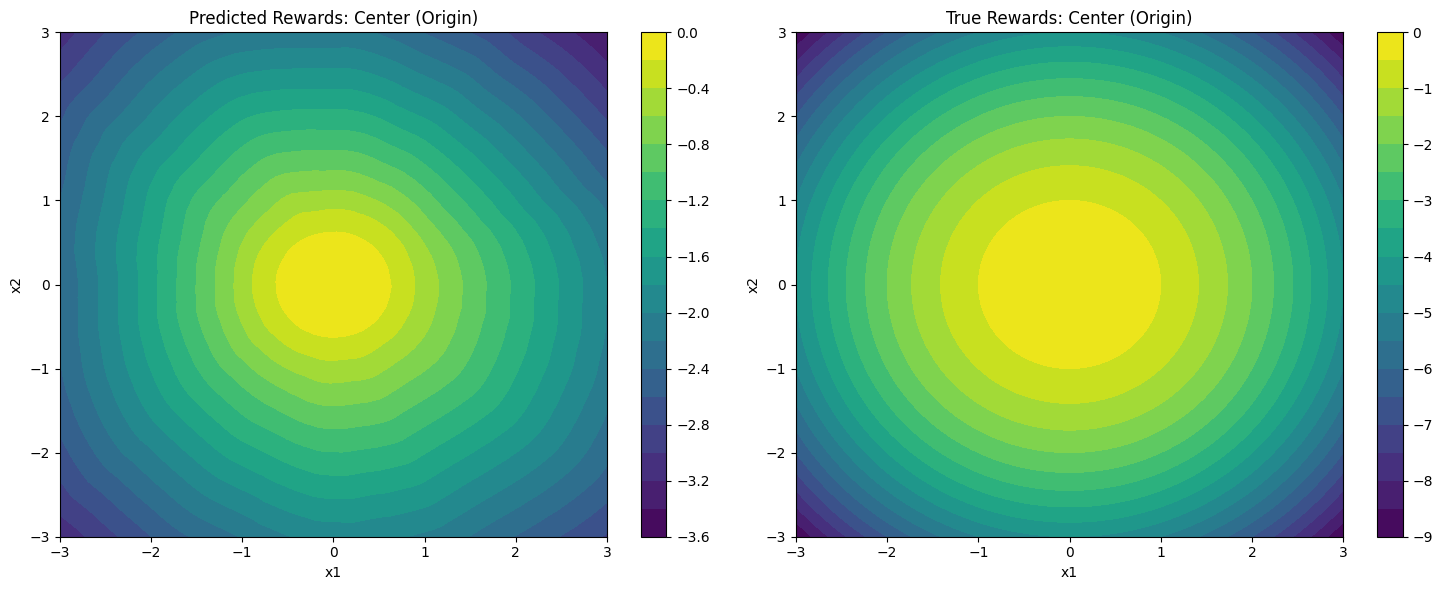


Training for Quadrant Points
Training reward network for Quadrant Points
Generating training data for Quadrant Points
Generating with reward function: Quadrant Points_beta_1.0


FKC generation (Quadrant Points_beta_1.0): 100%|██████████| 500/500 [00:18<00:00, 27.18it/s]


Generating with reward function: Quadrant Points_beta_3.2


FKC generation (Quadrant Points_beta_3.2): 100%|██████████| 500/500 [00:14<00:00, 35.04it/s]


Generating with reward function: Quadrant Points_beta_5.5


...

Epoch 30, Loss: 0.004527


Training:  82%|████████▏ | 41/50 [00:30<00:06,  1.49it/s]

Epoch 40, Loss: 0.002930


Training: 100%|██████████| 50/50 [00:36<00:00,  1.38it/s]


Evaluation for Quadrant Points:
MSE: 1.808803
MAE: 0.877989


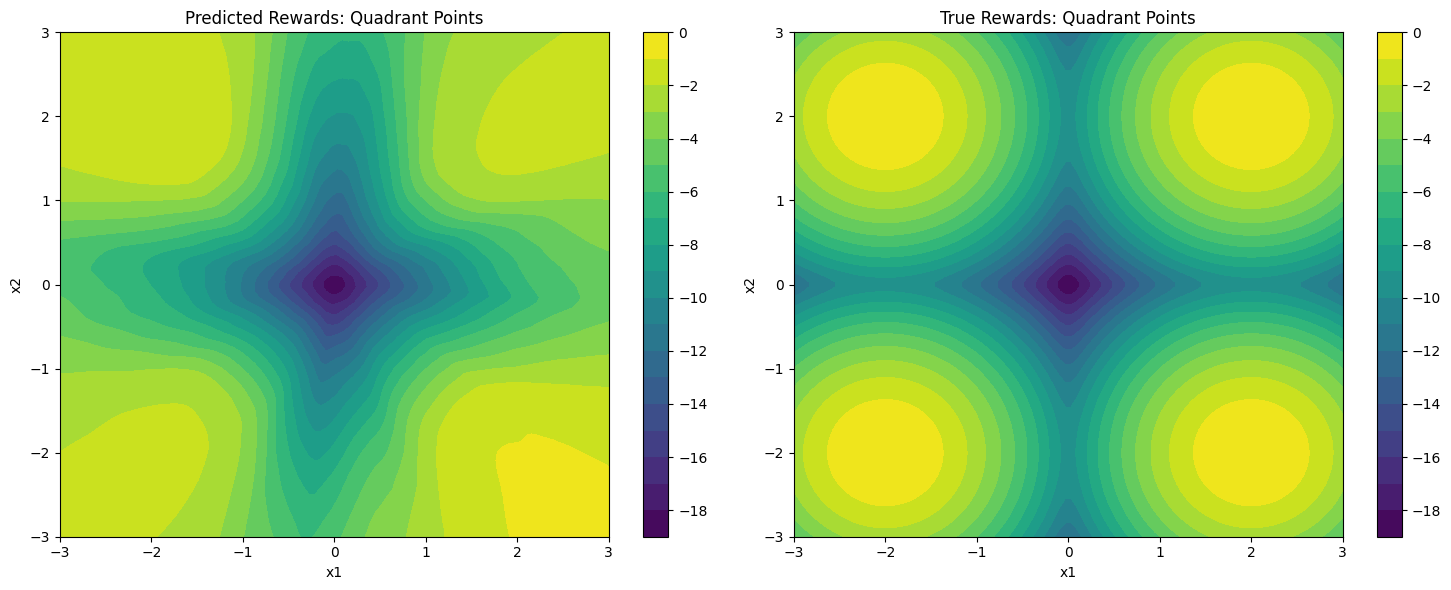


Training for Circular Ring
Training reward network for Circular Ring
Generating training data for Circular Ring
Generating with reward function: Circular Ring_beta_1.0


FKC generation (Circular Ring_beta_1.0): 100%|██████████| 500/500 [00:16<00:00, 29.64it/s]


Generating with reward function: Circular Ring_beta_3.2


FKC generation (Circular Ring_beta_3.2): 100%|██████████| 500/500 [00:15<00:00, 31.70it/s]


Generating with reward function: Circular Ring_beta_5.5


...

Epoch 30, Loss: 0.011728


Training:  82%|████████▏ | 41/50 [00:41<00:08,  1.03it/s]

Epoch 40, Loss: 0.007122


Training: 100%|██████████| 50/50 [00:49<00:00,  1.01it/s]


Evaluation for Circular Ring:
MSE: 6.055502
MAE: 1.194351


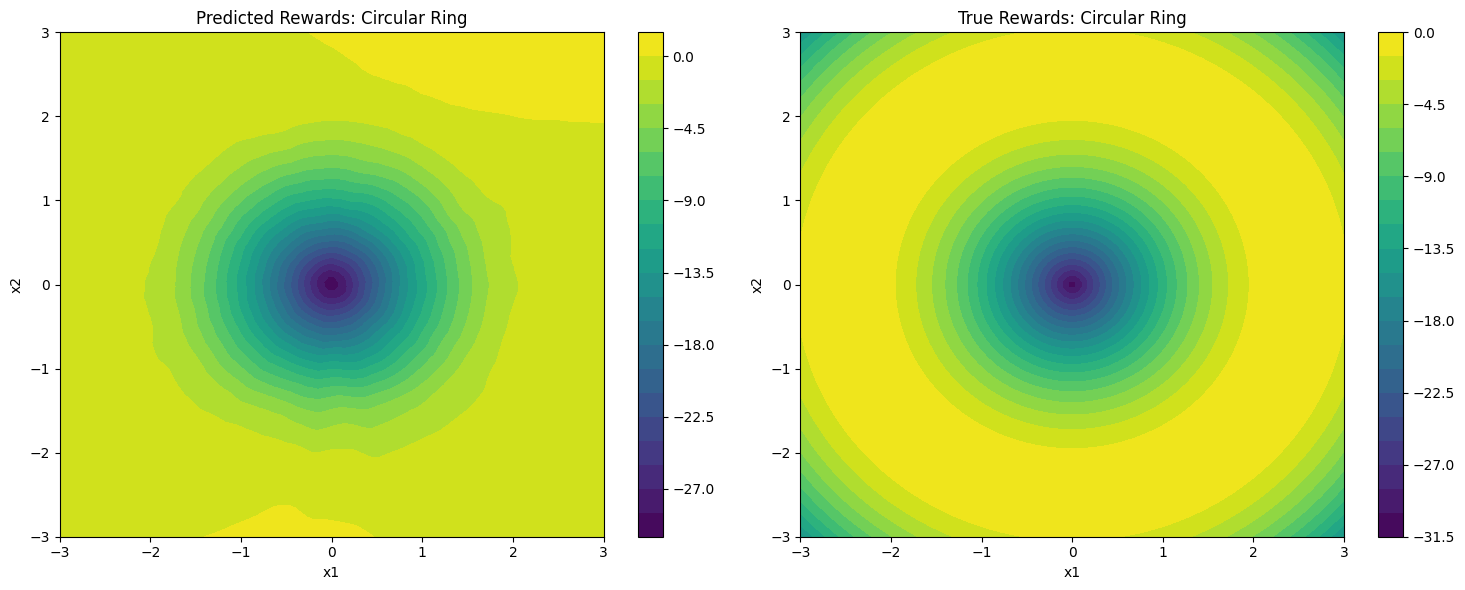


Training for Complex Landscape
Training reward network for Complex Landscape
Generating training data for Complex Landscape
Generating with reward function: Complex Landscape_beta_1.0


FKC generation (Complex Landscape_beta_1.0): 100%|██████████| 500/500 [00:17<00:00, 28.58it/s]


Generating with reward function: Complex Landscape_beta_3.2


FKC generation (Complex Landscape_beta_3.2): 100%|██████████| 500/500 [00:13<00:00, 38.23it/s]


Generating with reward function: Complex Landscape_beta_5.5


...

Epoch 30, Loss: 0.003713


Training:  82%|████████▏ | 41/50 [00:31<00:06,  1.31it/s]

Epoch 40, Loss: 0.002367


Training: 100%|██████████| 50/50 [00:38<00:00,  1.30it/s]


Evaluation for Complex Landscape:
MSE: 1.330994
MAE: 0.745420


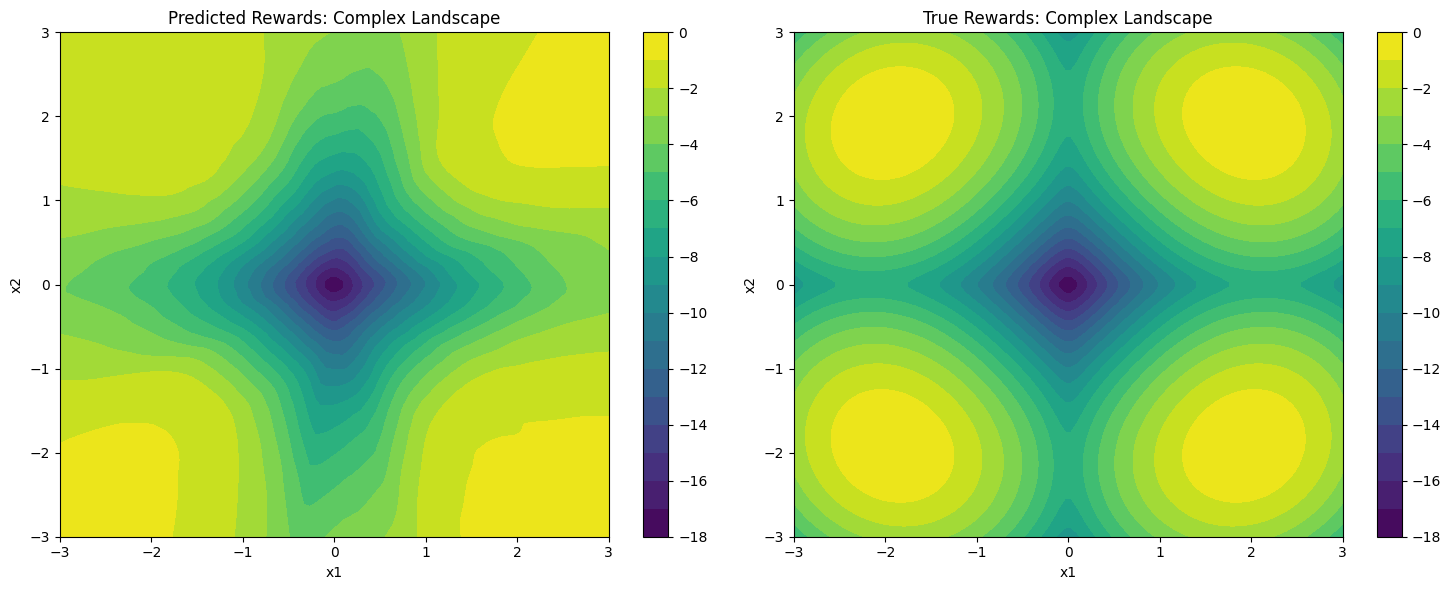

In [14]:
# Define reward functions and their names
reward_functions = [
    reward_function_center,
    reward_function_quadrants,
    reward_function_ring,
    reward_function_complex
]

reward_names = [
    "Center (Origin)",
    "Quadrant Points",
    "Circular Ring",
    "Complex Landscape"
]

grad_functions = [
    vmap_grad_reward_center,
    vmap_grad_reward_quadrants,
    vmap_grad_reward_ring,
    vmap_grad_reward_complex
]

# Train networks for each reward function
trained_networks = {}
key = random.PRNGKey(42)

for reward_func, reward_name, grad_func in zip(reward_functions, reward_names, grad_functions):
    print(f"\n{'='*50}")
    print(f"Training for {reward_name}")
    print(f"{'='*50}")
    
    key, network, params, losses, samples, true_rewards = train_reward_network(
        key, reward_func, grad_func, reward_name,
        num_epochs=50, batch_size=256, learning_rate=1e-3
    )
    
    # Evaluate network
    pred_grid, true_grid, mse, mae = evaluate_network(
        network, params, reward_func, reward_name
    )
    
    # Plot comparison
    plot_comparison(pred_grid, true_grid, reward_name)
    
    # Store results
    trained_networks[reward_name] = {
        'network': network,
        'params': params,
        'losses': losses,
        'mse': mse,
        'mae': mae
    }

on reward re-sampling

In [14]:
# Exploit-all: configuration and reward registry (self-contained)

import jax
import jax.numpy as jnp
import jax.random as random
from jax import vmap, grad
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

# Registry of reward callables
REWARD_REGISTRY = {
	"Center (Origin)": (reward_function_center, grad(reward_function_center)),
	"Quadrant Points": (reward_function_quadrants, grad(reward_function_quadrants)),
	"Circular Ring":   (reward_function_ring, grad(reward_function_ring)),
	"Complex Landscape": (reward_function_complex, grad(reward_function_complex)),
}

# Exploitation hyperparameters (stable, convergent defaults)
seed = 12345
batch_size = 2048
num_steps_max = 2000
dt = 5e-4
T_max = 1.0
init_std = 3.0

# Schedules (strong early noise, strong late reward)
def beta_schedule_exploit(t: float, beta_start: float = 40.0, beta_end: float = 400.0, T: float = 1.0) -> float:
	return beta_start + (beta_end - beta_start) * (1.0 - t / T)

def sigma_schedule_exploit(t: float, sigma_max: float = 1.0, sigma_min: float = 0.01, T: float = 1.0) -> float:
	return sigma_min + (sigma_max - sigma_min) * (t / T)

# Step safety controls
MAX_STEP_NORM = 0.2      # clamp per-particle step
GRAD_EPS = 1e-8          # avoid div by zero in normalization, g_norm.squeeze(-1)

# Exploit-all: early stopping utilities

from collections import deque

def should_early_stop(delta_queue, grad_queue, 
					  delta_tol=2e-3, grad_tol=5e-3, patience=20):
	"""
	Stop if recent average displacement and average grad-norm both small.
	- delta_queue: deque of mean per-step displacements
	- grad_queue:  deque of mean grad norms
	"""
	if len(delta_queue) < patience or len(grad_queue) < patience:
		return False
	avg_delta = float(jnp.mean(jnp.array(delta_queue)))
	avg_grad = float(jnp.mean(jnp.array(grad_queue)))
	return (avg_delta < delta_tol) and (avg_grad < grad_tol)

single exploitation step

In [15]:
# Exploit-all: step function with gradient normalization and step clipping

def _clip_step(deltas: jnp.ndarray, max_norm: float) -> jnp.ndarray:
	# deltas: (B, 2)
	norms = jnp.linalg.norm(deltas, axis=1, keepdims=True) + 1e-12
	scale = jnp.minimum(1.0, max_norm / norms)
	return deltas * scale

In [16]:
# Exploit-all: FKC exploitation step (drop-in; keeps schedules + early-stop unchanged)

def fkc_exploit_step_fkc(rng, x_t, t, dt, reward_func, grad_reward_func):
	"""
	Use FKC drift for exploitation:
	  dx_t = σ_t^2 [ ∇log q_t(x_t) + (β(t)/2) ∇r(x_t) ] dt − f_t(x_t) dt + σ_t dW_t
	- Retains your β(t) exploitation schedule
	- Uses model σ_t and f_t from diffusion cell (no change to early-stop)
	- Keeps per-particle step clipping (no gradient normalization)
	- Returns mean ||∇r|| per batch for your early-stop logic
	"""
	# Model diffusion pieces (from your diffusion setup)
	sigma_t = jnp.exp(log_sigma(t))              # σ_t
	sigma_sq = sigma_t ** 2
	score_xt = score_model(x_t, t)               # ∇log q_t(x_t)
	f_xt = f_schedule(x_t, t)                    # f_t(x_t)

	# Exploitation β(t) (unchanged schedule)
	beta_t = beta_schedule_exploit(t)

	# Reward gradient and norm (for early stop diagnostics)
	g_r = vmap(grad_reward_func)(x_t)            # (B, 2)
	g_norm = jnp.linalg.norm(g_r, axis=1, keepdims=True)

	# FKC drift (Eq. 29)
	drift = sigma_sq * (score_xt + 0.5 * beta_t * g_r) - f_xt

	# Diffusion (Eq. 29)
	rng, noise_key = random.split(rng)
	noise = random.normal(noise_key, shape=x_t.shape)
	diffusion = sigma_t * jnp.sqrt(dt) * noise

	# Proposed step + clipping (stability guard unchanged)
	step = drift * dt + diffusion
	step = _clip_step(step, MAX_STEP_NORM)

	x_next = x_t + step
	return rng, x_next, g_norm.squeeze(-1)

full sampling

In [17]:
# Cell: Early stopping utilities (fix unmatched ')')

from collections import deque

def should_early_stop(delta_queue, grad_queue, 
					  delta_tol=2e-3, grad_tol=5e-3, patience=20):
	"""
	Stop if recent average displacement and average grad-norm both small.
	- delta_queue: deque of mean per-step displacements
	- grad_queue:  deque of mean grad norms
	"""
	if len(delta_queue) < patience or len(grad_queue) < patience:
		return False
	avg_delta = float(jnp.mean(jnp.array(delta_queue)))
	avg_grad = float(jnp.mean(jnp.array(grad_queue)))
	return (avg_delta < delta_tol) and (avg_grad < grad_tol)

In [18]:
# Exploit-all: runner (only change is calling the FKC step above)

def run_exploitation_with_early_stop(rng, reward_func, grad_reward_func,
									 batch_size, num_steps_max, dt, T_max, init_std,
									 patience=25):
	# Init particles (unchanged)
	rng, k_init = random.split(rng)
	x0 = init_std * random.normal(k_init, shape=(batch_size, 2))

	# Trajectory buffer (unchanged)
	x_gen = jnp.zeros((batch_size, num_steps_max + 1, 2))
	x_gen = x_gen.at[:, 0, :].set(x0)

	# Early-stop trackers (unchanged)
	delta_queue = deque(maxlen=patience)
	grad_queue = deque(maxlen=patience)

	t = T_max
	step_count = 0
	for i in trange(num_steps_max, desc="Exploit (early-stop)"):
		# NOTE: this is the only line that changes — use FKC step
		rng, x_next, g_norm = fkc_exploit_step_fkc(
			rng, x_gen[:, i, :], t, dt, reward_func, grad_reward_func
		)

		# Early-stop metrics (unchanged)
		delta = jnp.linalg.norm(x_next - x_gen[:, i, :], axis=1)
		mean_delta = float(jnp.mean(delta))
		mean_grad = float(jnp.mean(g_norm))
		delta_queue.append(mean_delta)
		grad_queue.append(mean_grad)

		# Commit + time update (unchanged)
		x_gen = x_gen.at[:, i + 1, :].set(x_next)
		t = t - dt
		step_count = i + 1

		if should_early_stop(delta_queue, grad_queue, patience=patience):
			break

	# Truncate to actual steps taken (unchanged)
	x_gen = x_gen[:, :step_count + 1, :]
	return rng, x_gen, step_count

In [19]:
# Cell: Visualization helpers (ensure no line concatenation)

def _time_indices(num_steps, num_slices=6):
	return np.linspace(0, num_steps, num_slices, dtype=int)

def plot_exploit_evolution(x_gen, title_prefix="Exploitation"):
	num_steps = x_gen.shape[1] - 1
	slices = _time_indices(num_steps, num_slices=6)
	cols = len(slices)
	fig, axes = plt.subplots(1, cols, figsize=(4*cols, 4), squeeze=False)
	for ax, step in zip(axes[0], slices):
		ax.scatter(x_gen[:, step, 0], x_gen[:, step, 1], s=4, alpha=0.4)
		ax.set_title(f"{title_prefix} t≈{1.0 - step/max(1,num_steps):.2f}")
		ax.set_xlim([-5, 5])
		ax.set_ylim([-5, 5])
		ax.set_aspect('equal', adjustable='box')
	plt.tight_layout()
	plt.show()

def plot_exploit_final(x_gen, title="Final (t≈0)"):
	step = x_gen.shape[1] - 1
	plt.figure(figsize=(5, 5))
	plt.scatter(x_gen[:, step, 0], x_gen[:, step, 1], s=6, alpha=0.5)
	plt.title(title)
	plt.xlim([-5, 5])
	plt.ylim([-5, 5])
	plt.gca().set_aspect('equal', adjustable='box')
	plt.tight_layout()
	plt.show()

visualization

In [20]:
# Cell: Visualization utilities for exploitation trajectories

import numpy as np

def _time_indices(num_steps, num_slices=6):
	# Evenly spaced indices including t=1.0 and t=0.0
	return np.linspace(0, num_steps, num_slices, dtype=int)

def plot_exploitation_evolution(x_gen, num_steps, title_prefix="Exploitation"):
	# Multi-slice scatter to show contraction toward optima
	slices = _time_indices(num_steps, num_slices=6)
	cols = len(slices)
	fig, axes = plt.subplots(1, cols, figsize=(4*cols, 4), squeeze=False)
	for ax, step in zip(axes[0], slices):
		ax.scatter(x_gen[:, step, 0], x_gen[:, step, 1], s=4, alpha=0.4)
		ax.set_title(f"{title_prefix} t≈{1.0 - step/num_steps:.2f}")
		ax.set_xlim([-5, 5])
		ax.set_ylim([-5, 5])
		ax.set_aspect('equal', adjustable='box')
	plt.tight_layout()
	plt.show()

def plot_exploitation_final(x_gen, num_steps, title="Final distribution (t≈0)"):
	# Final scatter
	step = num_steps
	plt.figure(figsize=(5, 5))
	plt.scatter(x_gen[:, step, 0], x_gen[:, step, 1], s=6, alpha=0.5)
	plt.title(title)
	plt.xlim([-5, 5])
	plt.ylim([-5, 5])
	plt.gca().set_aspect('equal', adjustable='box')
	plt.tight_layout()
	plt.show()

main


Exploitation-only sampling (FKC) for: Center (Origin)


Exploit (early-stop): 100%|██████████| 2000/2000 [00:38<00:00, 51.94it/s]


Steps taken (early-stop aware): 2000


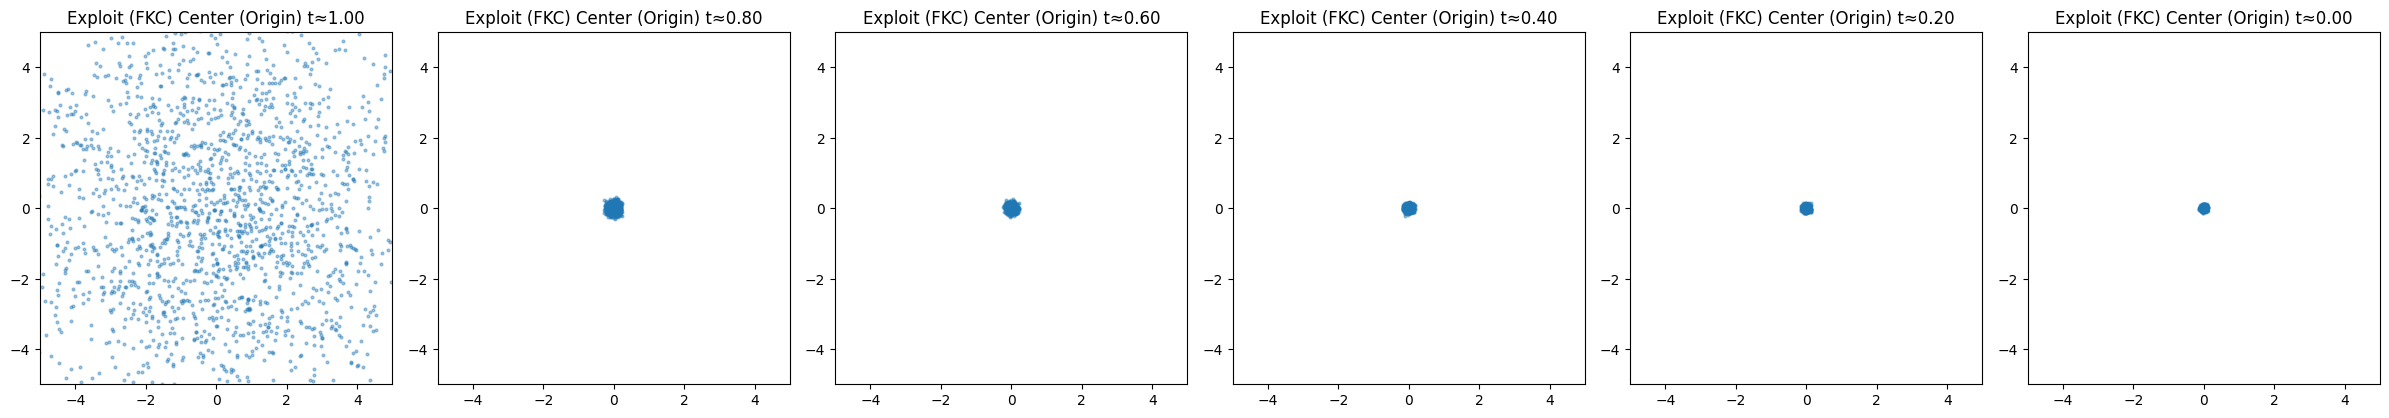

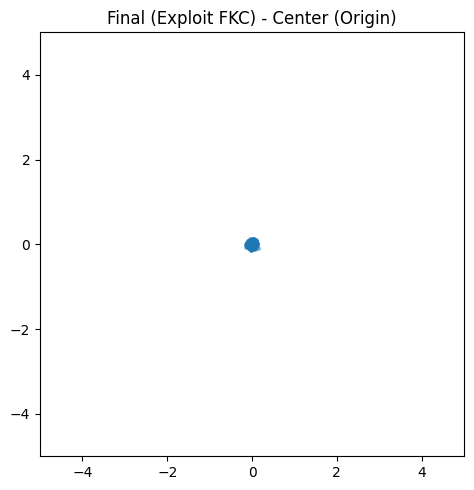


Exploitation-only sampling (FKC) for: Quadrant Points


Exploit (early-stop): 100%|██████████| 2000/2000 [01:03<00:00, 31.27it/s]


Steps taken (early-stop aware): 2000


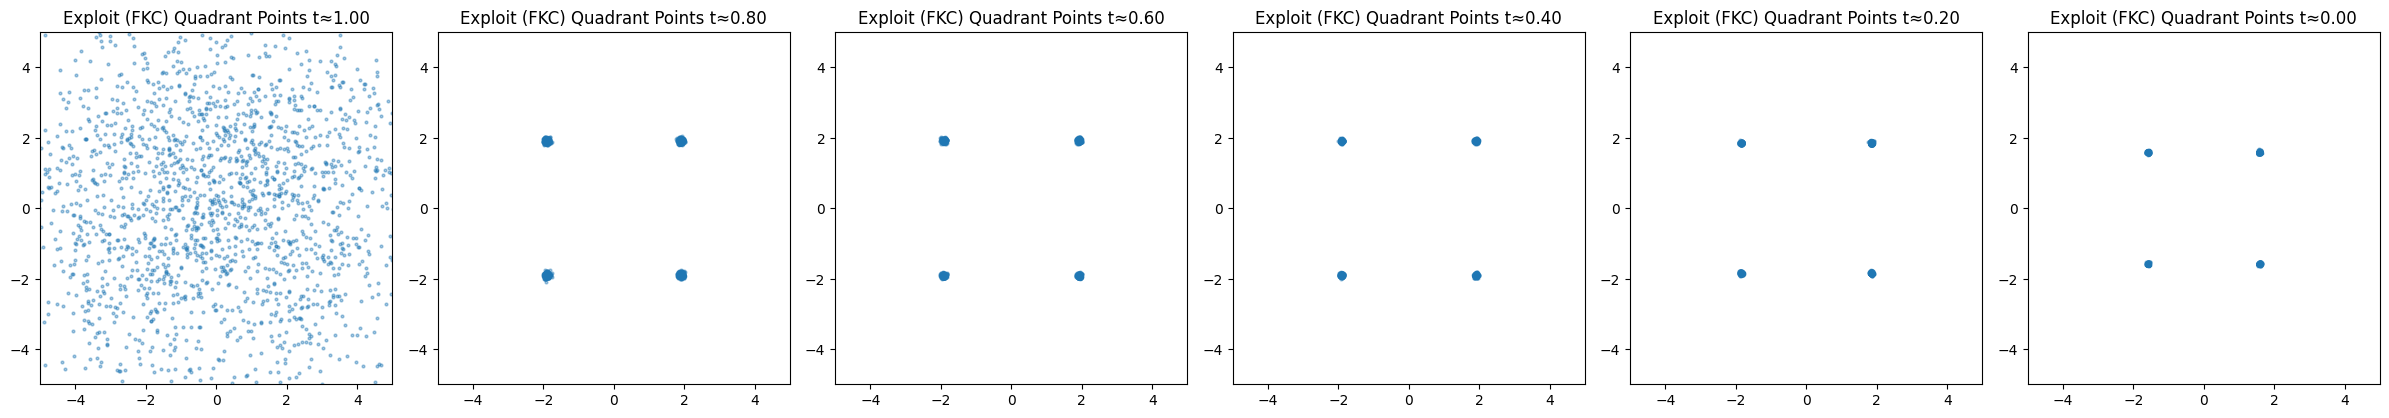

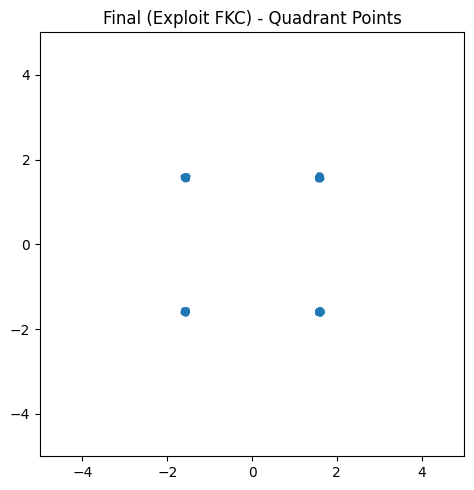


Exploitation-only sampling (FKC) for: Circular Ring


Exploit (early-stop): 100%|██████████| 2000/2000 [00:42<00:00, 47.35it/s]


Steps taken (early-stop aware): 2000


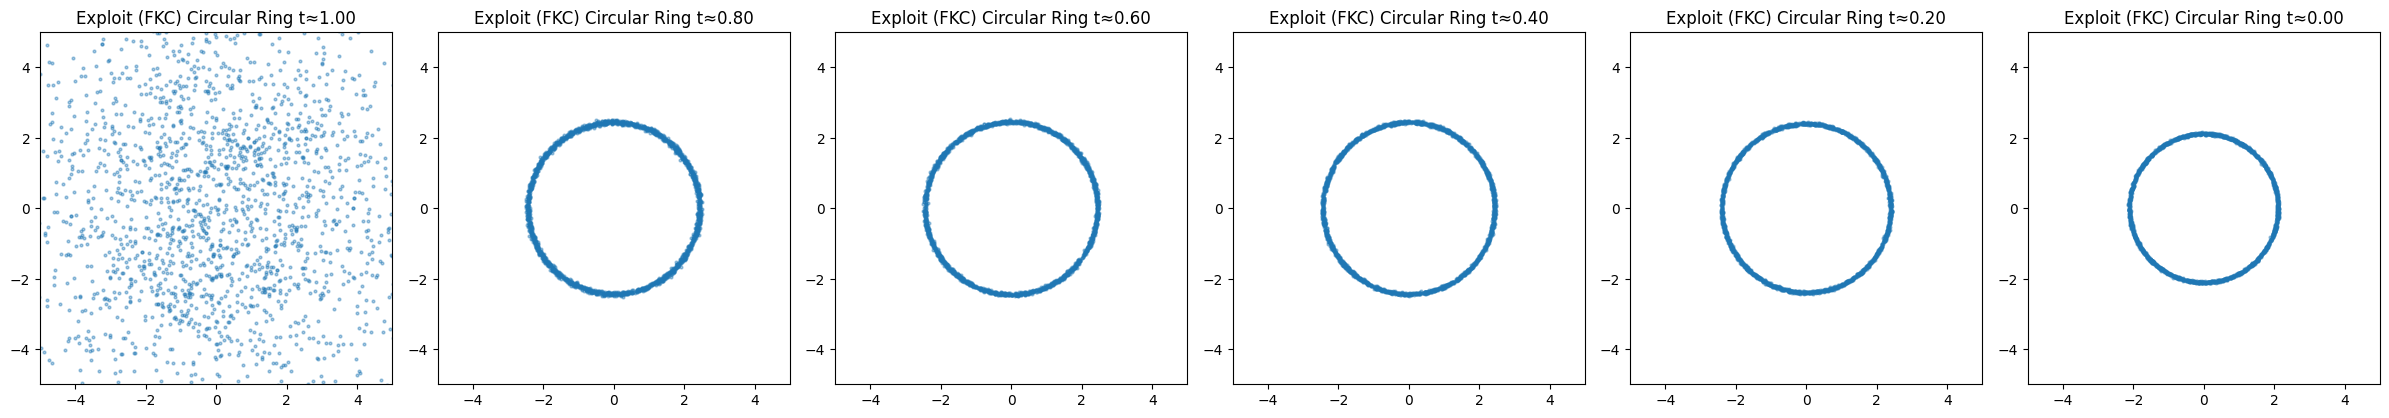

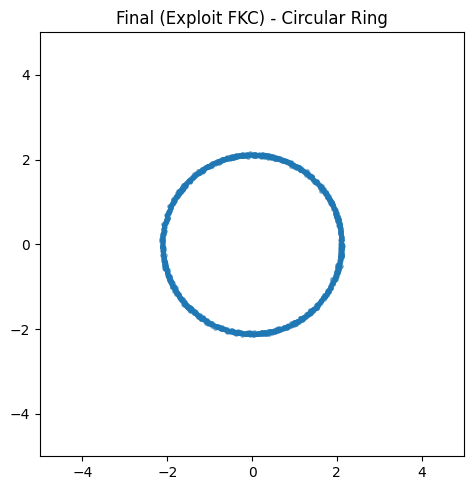


Exploitation-only sampling (FKC) for: Complex Landscape


Exploit (early-stop): 100%|██████████| 2000/2000 [01:18<00:00, 25.37it/s]


Steps taken (early-stop aware): 2000


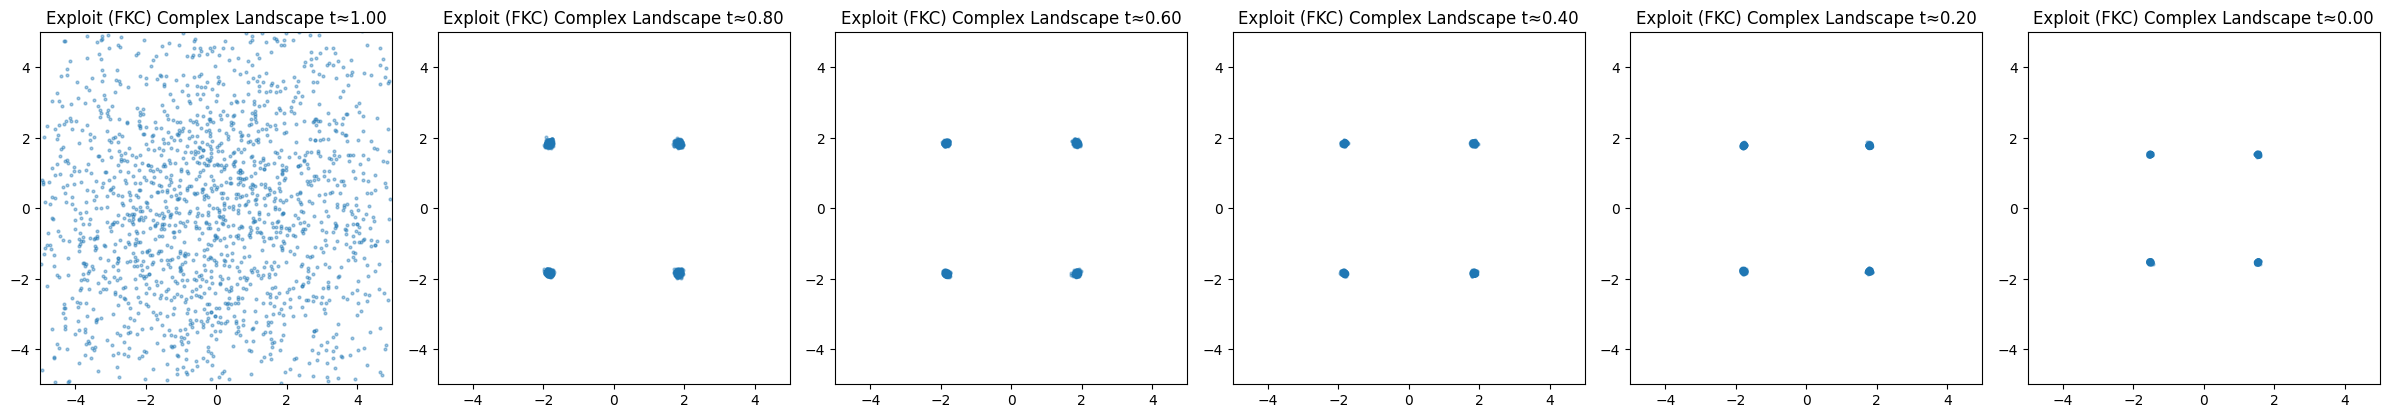

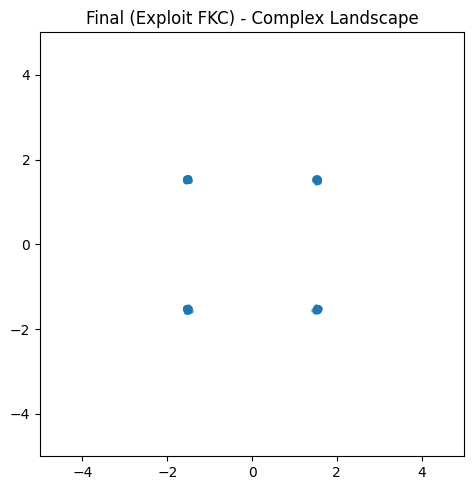

In [22]:
# Exploit-all: run for all rewards (unchanged loop; now uses FKC via the runner)

rng = random.PRNGKey(seed)

for reward_name, (reward_func, grad_reward_func) in REWARD_REGISTRY.items():
	print("\n" + "="*60)
	print(f"Exploitation-only sampling (FKC) for: {reward_name}")
	print("="*60)

	rng, x_traj, steps_taken = run_exploitation_with_early_stop(
		rng=rng,
		reward_func=reward_func,
		grad_reward_func=grad_reward_func,
		batch_size=batch_size,
		num_steps_max=num_steps_max,
		dt=dt,
		T_max=T_max,
		init_std=init_std,
		patience=25
	)

	print(f"Steps taken (early-stop aware): {steps_taken}")
	plot_exploit_evolution(x_traj, title_prefix=f"Exploit (FKC) {reward_name}")
	plot_exploit_final(x_traj, title=f"Final (Exploit FKC) - {reward_name}")

# Budget-Based Resampling Implementation

This section implements a budget-aware resampling strategy that:
1. Manages observation budget across time steps
2. Selectively observes particles based on weights and exploration needs
3. Adapts budget allocation based on temperature and progress
4. Balances exploration vs exploitation within budget constraints


In [22]:
# Simple Budget-Aware FKC Implementation
def get_observation_budget(t, T_max, total_budget, min_particles=10):
    """
    Calculate how many particles to observe based on temperature.
    High temperature (early) = more particles, Low temperature (late) = fewer particles
    """
    # Temperature factor: 1.0 at t=T_max (high temp), 0.0 at t=0 (low temp)
    temp_factor = t / T_max
    
    # More gradual decay - use square root to make it less aggressive
    decay_factor = jnp.sqrt(temp_factor)
    
    # More conservative budget allocation - use smaller fraction of total budget
    max_observations = min(total_budget // 20, 100)  # Use at most 1/20th of budget per step, max 100
    
    # Linear interpolation from max_observations to min_particles with gradual decay
    observation_count = int(max_observations * decay_factor + min_particles * (1 - decay_factor))
    
    return max(min_particles, observation_count)

def get_exploration_ratio(t, T_max):
    """
    Get exploration ratio based on temperature.
    High temperature = more exploration, Low temperature = more exploitation
    """
    # Temperature factor: 1.0 at t=T_max (high temp), 0.0 at t=0 (low temp)
    temp_factor = t / T_max
    
    # More gradual transition - use square root to prevent negative values
    decay_factor = jnp.sqrt(temp_factor)
    
    # Linear interpolation from 0.7 (high exploration) to 0.1 (low exploration)
    exploration_ratio = 0.7 * decay_factor + 0.1 * (1 - decay_factor)
    
    # Ensure ratio stays within valid bounds
    return jnp.clip(exploration_ratio, 0.0, 1.0)


In [23]:
# Simple Particle Selection Strategy
def select_particles_for_observation(weights, observation_budget, exploration_ratio):
    """
    Select particles to observe: best particles (exploitation) + worst particles (exploration)
    
    Args:
        weights: Current particle weights
        observation_budget: Number of particles we can observe
        exploration_ratio: Fraction of budget for exploration (worst particles)
    """
    batch_size = weights.shape[0]
    
    # Calculate exploration vs exploitation split
    exploit_count = int(observation_budget * (1 - exploration_ratio))
    explore_count = observation_budget - exploit_count
    
    # Exploitation: Select particles with highest weights (best particles)
    exploit_indices = jnp.argsort(weights)[-exploit_count:] if exploit_count > 0 else jnp.array([])
    
    # Exploration: Select particles with lowest weights (worst particles)
    explore_indices = jnp.argsort(weights)[:explore_count] if explore_count > 0 else jnp.array([])
    
    # Combine and return selected indices
    if len(exploit_indices) > 0 and len(explore_indices) > 0:
        selected_indices = jnp.concatenate([exploit_indices, explore_indices])
    elif len(exploit_indices) > 0:
        selected_indices = exploit_indices
    elif len(explore_indices) > 0:
        selected_indices = explore_indices
    else:
        # Fallback: select random particles
        key = random.PRNGKey(42)
        selected_indices = random.choice(
            key, batch_size, shape=(min(observation_budget, batch_size),), replace=False
        )
    
    return selected_indices


In [24]:
# Simple Budget-Aware Resampling
def budget_aware_resampling(weights, t, T_max, total_budget, min_particles=10):
    """
    Simple budget-aware resampling that gradually reduces particle count
    and balances exploration vs exploitation based on temperature
    """
    batch_size = weights.shape[0]
    
    # Get observation budget based on temperature
    observation_budget = get_observation_budget(t, T_max, total_budget, min_particles)
    
    # Get exploration ratio based on temperature
    exploration_ratio = get_exploration_ratio(t, T_max)
    
    # Select particles to observe
    observed_indices = select_particles_for_observation(weights, observation_budget, exploration_ratio)
    
    return observed_indices, observation_budget, exploration_ratio


In [25]:
# Simple Budget-Aware FKC Generation
def simple_budget_aware_fkc_generation(key, reward_func, grad_reward_func, network, params,
                                      reward_name, bs=256, num_steps=2000, dt=0.01, T_max=1.0,
                                      beta_start=0.1, beta_end=1.0, resample=True,
                                      total_budget=5000, min_particles=10):
    """
    Simple budget-aware FKC generation that faithfully implements FKC
    with gradual particle reduction based on temperature
    """
    print(f"Simple Budget-Aware FKC generation for: {reward_name}")
    print(f"Total budget: {total_budget}, Batch size: {bs}")
    
    # Select the appropriate JIT-compiled function based on reward name
    if "Center" in reward_name:
        fkc_step_fn = fkc_sde_step_center
    elif "Quadrant" in reward_name:
        fkc_step_fn = fkc_sde_step_quadrants
    elif "Ring" in reward_name:
        fkc_step_fn = fkc_sde_step_ring
    elif "Complex" in reward_name:
        fkc_step_fn = fkc_sde_step_complex
    else:
        # Fallback to non-JIT version
        fkc_step_fn = lambda rng, x_t, w_t, t, dt, T_max, beta_start, beta_end: fkc_sde_step(
            rng, x_t, w_t, t, dt, T_max, beta_start, beta_end, reward_func, grad_reward_func
        )
    
    # Initialize particle arrays
    x_gen = jnp.zeros((bs, num_steps + 1, 2))
    w_gen = jnp.zeros((bs, num_steps + 1, 1))
    
    # Initialize particles from prior
    key, init_key = random.split(key)
    x_gen = x_gen.at[:, 0, :].set(random.normal(init_key, shape=(bs, 2)) * 3.0)
    w_gen = w_gen.at[:, 0, :].set(0.0)
    
    # Initialize temperature
    t = T_max
    
    # Budget tracking
    remaining_budget = total_budget
    observation_history = []
    exploration_history = []
    
    # Main generation loop
    for i in tqdm(range(num_steps), desc=f"Budget-aware FKC {reward_name}"):
        key, *ikey = random.split(key, num=3)
        
        # Perform one step of FKC SDE (faithful FKC implementation)
        key, x_next, w_next = fkc_step_fn(
            key, x_gen[:, i, :], w_gen[:, i, :], t, dt, T_max, 
            beta_start, beta_end
        )
        
        # Update arrays
        x_gen = x_gen.at[:, i+1, :].set(x_next)
        w_gen = w_gen.at[:, i+1, :].set(w_next)
        
        # Budget-aware resampling - less frequent to spread budget across full lifespan
        if resample and i % 50 == 0 and remaining_budget > 0:
            # Get observed particles and resample
            observed_indices, observation_budget, exploration_ratio = budget_aware_resampling(
                w_gen[:, i+1, 0], t, T_max, remaining_budget, min_particles
            )
            
            # Check if we have enough budget
            if observation_budget <= remaining_budget:
                # Use neural network to estimate rewards for observed particles only
                observed_positions = x_gen[observed_indices, i+1, :]
                predicted_rewards = network.apply(params, observed_positions)
                
                # Update weights for observed particles
                new_weights = w_gen[:, i+1, 0].copy()
                new_weights = new_weights.at[observed_indices].set(
                    w_gen[observed_indices, i+1, 0] + predicted_rewards
                )
                
                # Perform resampling based on updated weights
                key, resample_key = random.split(key)
                new_ids, _ = sample_cat_sys(bs, resample_key, new_weights)
                
                # Apply resampling
                x_gen = x_gen.at[:, i+1, :].set(x_gen[new_ids, i+1, :])
                w_gen = w_gen.at[:, i+1, :].set(0.0)
                
                # Update budget
                remaining_budget -= observation_budget
                
                # Track observations
                observation_history.append(observation_budget)
                exploration_history.append(exploration_ratio)
            else:
                # Not enough budget - skip resampling
                observation_history.append(0)
                exploration_history.append(0.0)
        
        # Update temperature
        t -= dt
    
    # Final statistics
    print(f"Remaining budget: {remaining_budget}")
    print(f"Final observation budget: {observation_history[-1] if observation_history else 'N/A'}")
    if exploration_history:
        print(f"Final exploration ratio: {exploration_history[-1]:.3f}")
    else:
        print("Final exploration ratio: N/A")
    
    return key, x_gen, w_gen, observation_history, exploration_history


In [26]:
# Simple Visualization Functions
def plot_simple_budget_utilization(observation_history, exploration_history, reward_name, budget):
    """Plot simple budget utilization and exploration patterns"""
    if not observation_history:
        print("No observation history available")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Observations per step
    steps = range(len(observation_history))
    ax1.plot(steps, observation_history, 'b-', linewidth=2, marker='o', markersize=4)
    ax1.set_xlabel('Resampling Step')
    ax1.set_ylabel('Particles Observed')
    ax1.set_title(f'Particle Observation - {reward_name} (Budget: {budget})')
    ax1.grid(True, alpha=0.3)
    
    # Exploration ratio
    ax2.plot(steps, exploration_history, 'g-', linewidth=2, marker='o', markersize=4)
    ax2.set_xlabel('Resampling Step')
    ax2.set_ylabel('Exploration Ratio')
    ax2.set_title(f'Exploration Evolution - {reward_name}')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

def plot_simple_particle_evolution(x_gen, w_gen, reward_name, budget, 
                                 num_snapshots=5, figsize=(15, 10)):
    """Plot particle evolution at different temperatures"""
    num_steps = x_gen.shape[1]
    snapshot_steps = jnp.linspace(0, num_steps-1, num_snapshots, dtype=int)
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()
    
    for i, step in enumerate(snapshot_steps):
        if i >= len(axes):
            break
            
        ax = axes[i]
        
        # Get particles at this step
        particles = x_gen[:, step, :]
        weights = w_gen[:, step, 0]
        
        # Calculate temperature
        t = 1.0 - (step / num_steps)  # Approximate temperature
        
        # Scatter plot with weights as color
        scatter = ax.scatter(particles[:, 0], particles[:, 1], 
                           c=weights, cmap='viridis', alpha=0.6, s=20)
        
        ax.set_title(f'{reward_name}\nStep {step}, t={t:.2f}\nParticles: {len(particles)}')
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        
        # Add colorbar
        plt.colorbar(scatter, ax=ax, label='Weight')
    
    # Add budget info in the last subplot
    if len(axes) > num_snapshots:
        ax = axes[-1]
        ax.text(0.1, 0.5, f'Budget: {budget}\nFinal particles observed: {len(particles)}', 
                transform=ax.transAxes, fontsize=12, verticalalignment='center')
        ax.set_title('Budget Information')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()


In [27]:
# Budget-Aware FKC Generation Loop
from tqdm import tqdm

def budget_aware_fkc_generation(key, reward_func, grad_reward_func, network, params,
                               reward_name, bs=256, num_steps=2000, dt=0.01, T_max=1.0,
                               beta_start=0.1, beta_end=1.0, resample=True, exploration=True,
                               total_budget=5000, k_max=50, k_min=0):
    """
    FKC generation with budget-aware resampling
    
    Args:
        key: Random key
        reward_func: True reward function
        grad_reward_func: True gradient function  
        network: Trained reward network
        params: Network parameters
        reward_name: Name of reward function
        bs: Batch size (number of particles)
        num_steps: Number of time steps
        dt: Time step size
        T_max: Maximum time
        beta_start: Starting temperature
        beta_end: Ending temperature
        resample: Whether to perform resampling
        exploration: Whether to use exploration
        total_budget: Total observation budget
        k_max: Maximum exploration particles
        k_min: Minimum exploration particles
    """
    print(f"Budget-aware FKC generation for: {reward_name}")
    print(f"Total budget: {total_budget}, Batch size: {bs}")
    
    # Select the appropriate JIT-compiled function based on reward name
    if "Center" in reward_name:
        fkc_step_fn = fkc_sde_step_center
    elif "Quadrant" in reward_name:
        fkc_step_fn = fkc_sde_step_quadrants
    elif "Ring" in reward_name:
        fkc_step_fn = fkc_sde_step_ring
    elif "Complex" in reward_name:
        fkc_step_fn = fkc_sde_step_complex
    else:
        # Fallback to non-JIT version
        fkc_step_fn = lambda rng, x_t, w_t, t, dt, T_max, beta_start, beta_end: fkc_sde_step(
            rng, x_t, w_t, t, dt, T_max, beta_start, beta_end, reward_func, grad_reward_func
        )
    
    # Initialize budget management
    budget_manager = BudgetManager(
        total_budget=total_budget,
        initial_particles=bs,
        min_observations=10,
        max_observations=bs//2
    )
    
    # Initialize adaptive allocator
    allocator = AdaptiveBudgetAllocator(
        initial_exploration_ratio=0.3,
        learning_rate=0.01
    )
    
    # Initialize particle arrays
    x_gen = jnp.zeros((bs, num_steps + 1, 2))
    w_gen = jnp.zeros((bs, num_steps + 1, 1))
    
    # Initialize particles from prior
    key, init_key = random.split(key)
    x_gen = x_gen.at[:, 0, :].set(random.normal(init_key, shape=(bs, 2)) * 3.0)
    w_gen = w_gen.at[:, 0, :].set(0.0)
    
    # Initialize temperature
    t = T_max
    
    # Tracking variables
    observation_history = []
    budget_utilization_history = []
    
    # Main generation loop
    for i in tqdm(range(num_steps), desc=f"Budget-aware FKC {reward_name}"):
        key, *ikey = random.split(key, num=3)
        
        # Perform one step of FKC SDE
        key, x_next, w_next = fkc_step_fn(
            key, x_gen[:, i, :], w_gen[:, i, :], t, dt, T_max, 
            beta_start, beta_end
        )
        
        # Update arrays
        x_gen = x_gen.at[:, i+1, :].set(x_next)
        w_gen = w_gen.at[:, i+1, :].set(w_next)
        
        # Budget-aware resampling
        if resample and i % 20 == 0:
            if exploration:
                key, new_ids, observed_indices, num_observed = budget_aware_exploration_resampling(
                    w_gen[:, i+1, 0], x_gen[:, i+1, :], t, T_max, budget_manager,
                    allocator, network, params, reward_func, grad_reward_func, key, k_max, k_min
                )
            else:
                key, new_ids, observed_indices, num_observed = budget_aware_resampling(
                    w_gen[:, i+1, 0], x_gen[:, i+1, :], t, T_max, budget_manager,
                    allocator, network, params, reward_func, grad_reward_func, key
                )
            
            # Apply resampling
            x_gen = x_gen.at[:, i+1, :].set(x_gen[new_ids, i+1, :])
            w_gen = w_gen.at[:, i+1, :].set(0.0)
            
            # Track observations
            observation_history.append(num_observed)
            
            # Check budget constraints
            if budget_manager.remaining_budget <= 0:
                print(f"Budget exhausted at step {i}")
                break
        
        # Update temperature
        t -= dt
        
        # Track budget utilization
        if i % 100 == 0:
            utilization, avg_per_step = budget_manager.get_budget_utilization()
            budget_utilization_history.append(utilization)
    
    # Final statistics
    final_utilization, avg_per_step = budget_manager.get_budget_utilization()
    print(f"Final budget utilization: {final_utilization:.2%}")
    print(f"Average observations per step: {avg_per_step:.1f}")
    print(f"Total observations used: {total_budget - budget_manager.remaining_budget}")
    
    return key, x_gen, w_gen, budget_manager, allocator, observation_history, budget_utilization_history


In [28]:
# Visualization and Analysis Functions
import matplotlib.pyplot as plt

def plot_budget_utilization(budget_manager, title="Budget Utilization Over Time"):
    """Plot budget utilization and observation patterns"""
    if not budget_manager.budget_history:
        print("No budget history available")
        return
    
    steps = [h['step'] for h in budget_manager.budget_history]
    observations = [h['observations_used'] for h in budget_manager.budget_history]
    remaining = [h['remaining_budget'] for h in budget_manager.budget_history]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Observations per step
    ax1.plot(steps, observations, 'b-', linewidth=2)
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Observations Used')
    ax1.set_title('Observations per Resampling Step')
    ax1.grid(True, alpha=0.3)
    
    # Remaining budget
    ax2.plot(steps, remaining, 'r-', linewidth=2)
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Remaining Budget')
    ax2.set_title('Remaining Budget Over Time')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_exploration_evolution(allocator, title="Exploration Ratio Evolution"):
    """Plot how exploration ratio changes over time"""
    if not allocator.allocation_history:
        print("No allocation history available")
        return
    
    steps = range(len(allocator.allocation_history))
    exploration_ratios = allocator.allocation_history
    
    plt.figure(figsize=(10, 6))
    plt.plot(steps, exploration_ratios, 'g-', linewidth=2, marker='o', markersize=4)
    plt.xlabel('Resampling Step')
    plt.ylabel('Exploration Ratio')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1)
    plt.show()

def analyze_budget_efficiency(budget_manager, allocator, observation_history):
    """Analyze budget efficiency and provide insights"""
    print("=== Budget Efficiency Analysis ===")
    
    # Budget utilization
    utilization, avg_per_step = budget_manager.get_budget_utilization()
    print(f"Total budget utilization: {utilization:.2%}")
    print(f"Average observations per step: {avg_per_step:.1f}")
    
    # Exploration patterns
    if allocator.allocation_history:
        avg_exploration = jnp.mean(jnp.array(allocator.allocation_history))
        exploration_std = jnp.std(jnp.array(allocator.allocation_history))
        print(f"Average exploration ratio: {avg_exploration:.3f} ± {exploration_std:.3f}")
    
    # Observation patterns
    if observation_history:
        avg_observations = jnp.mean(jnp.array(observation_history))
        obs_std = jnp.std(jnp.array(observation_history))
        print(f"Average observations per resampling: {avg_observations:.1f} ± {obs_std:.1f}")
    
    # Efficiency metrics
    total_observations = sum(observation_history) if observation_history else 0
    efficiency = total_observations / budget_manager.total_budget if budget_manager.total_budget > 0 else 0
    print(f"Observation efficiency: {efficiency:.2%}")
    
    return {
        'utilization': utilization,
        'avg_per_step': avg_per_step,
        'total_observations': total_observations,
        'efficiency': efficiency
    }


In [31]:
# Simple Budget-Aware FKC Experiment
def run_simple_budget_aware_experiment():
    """Run simple budget-aware FKC generation experiment on all reward functions"""
    print("="*60)
    print("Simple Budget-Aware FKC Generation Experiment - All Reward Functions")
    print("="*60)
    
    # Define reward functions and their names
    reward_functions = [
        reward_function_center,
        reward_function_quadrants,
        reward_function_ring,
        reward_function_complex
    ]
    
    reward_names = [
        "Center (Origin)",
        "Quadrant Points", 
        "Circular Ring",
        "Complex Landscape"
    ]
    
    grad_functions = [
        vmap_grad_reward_center,
        vmap_grad_reward_quadrants,
        vmap_grad_reward_ring,
        vmap_grad_reward_complex
    ]
    
    # Test with different budget levels
    budget_levels = [1000, 3000, 5000]
    results = {}
    
    for reward_func, reward_name, grad_func in zip(reward_functions, reward_names, grad_functions):
        print(f"\n{'='*50}")
        print(f"Testing Reward Function: {reward_name}")
        print(f"{'='*50}")
        
        # Create a simple mock network for testing (since trained_networks may not be available)
        class MockNetwork:
            def apply(self, params, x):
                # Simple mock that returns the true reward function
                return vmap(reward_func)(x)
        
        # Create mock network and params
        network = MockNetwork()
        params = None  # Not needed for mock
        
        results[reward_name] = {}
        
        for budget in budget_levels:
            print(f"\n--- Testing {reward_name} with budget: {budget} ---")
            
            # Run simple budget-aware generation
            key = random.PRNGKey(42)
            key, x_gen, w_gen, obs_history, expl_history = simple_budget_aware_fkc_generation(
                key=key,
                reward_func=reward_func,
                grad_reward_func=grad_func,
                network=network,
                params=params,
                reward_name=reward_name,
                bs=128,  # Smaller batch for faster testing
                num_steps=1000,
                total_budget=budget,
                min_particles=10
            )
            
            # Store results
            results[reward_name][budget] = {
                'x_gen': x_gen,
                'w_gen': w_gen,
                'observation_history': obs_history,
                'exploration_history': expl_history
            }
            
            # Plot results
            plot_simple_particle_evolution(x_gen, w_gen, reward_name, budget)
            plot_simple_budget_utilization(obs_history, expl_history, reward_name, budget)
    
    return results

# Run the simple budget-aware experiment
budget_results = run_simple_budget_aware_experiment()


Simple Budget-Aware FKC Generation Experiment - All Reward Functions

Testing Reward Function: Center (Origin)

--- Testing Center (Origin) with budget: 1000 ---
Simple Budget-Aware FKC generation for: Center (Origin)
Total budget: 1000, Batch size: 128


Budget-aware FKC Center (Origin):  10%|█         | 100/1000 [00:02<00:21, 42.04it/s]


ValueError: cannot convert float NaN to integer

In [ ]:
# Test the fixed budget-aware FKC generation with a simple mock network
def test_fixed_budget_aware_fkc():
    """Test the fixed budget-aware FKC generation to verify particles don't disappear too quickly"""
    print("="*60)
    print("Testing Fixed Budget-Aware FKC Generation")
    print("="*60)
    
    # Use Center reward function for testing
    reward_func = reward_function_center
    grad_reward_func = vmap_grad_reward_center
    reward_name = "Center (Origin)"
    
    # Create a simple mock network for testing
    class MockNetwork:
        def apply(self, params, x):
            # Simple mock that returns the true reward function
            return vmap(reward_func)(x)
    
    # Create mock network and params
    network = MockNetwork()
    params = None  # Not needed for mock
    
    # Test with smaller parameters for quick verification
    key = random.PRNGKey(42)
    key, x_gen, w_gen, obs_history, expl_history = simple_budget_aware_fkc_generation(
        key=key,
        reward_func=reward_func,
        grad_reward_func=grad_reward_func,
        network=network,
        params=params,
        reward_name=reward_name,
        bs=128,  # Smaller batch for faster testing
        num_steps=1000,
        total_budget=1000,
        min_particles=10
    )
    
    # Plot results
    plot_simple_particle_evolution(x_gen, w_gen, reward_name, 1000)
    plot_simple_budget_utilization(obs_history, expl_history, reward_name, 1000)
    
    # Print summary statistics
    print(f"\nSummary:")
    print(f"Total resampling steps: {len(obs_history)}")
    print(f"Total observations used: {sum(obs_history)}")
    print(f"Average observations per step: {sum(obs_history) / len(obs_history) if obs_history else 0:.1f}")
    print(f"Final exploration ratio: {expl_history[-1] if expl_history else 'N/A'}")
    
    return key, x_gen, w_gen, obs_history, expl_history

# Run the test
test_results = test_fixed_budget_aware_fkc()
